<a href="https://colab.research.google.com/github/alihuss1017/KantoDex/blob/main/backend/notebooks/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import userdata
import os
os.environ['GH_TOKEN'] = userdata.get('GITHUB_TOKEN')

In [19]:
!git clone https://$GH_TOKEN@github.com/alihuss1017/KantoDex.git

fatal: destination path 'KantoDex' already exists and is not an empty directory.


In [3]:
import kagglehub

os.environ['KAGGLEHUB_CACHE'] = os.getcwd()
path = kagglehub.dataset_download("mikoajkolman/pokemon-images-first-generation17000-files")

100%|██████████| 2.81G/2.81G [02:13<00:00, 22.5MB/s]

Extracting files...


In [4]:
import shutil

src_dir = os.path.join('datasets', 'mikoajkolman', 'pokemon-images-first-generation17000-files', 'versions', '1', 'pokemon')
dest_dir = os.path.join('KantoDex/backend/data')

os.makedirs(dest_dir, exist_ok=True)

for folder in os.listdir(src_dir):
    src_path = os.path.join(src_dir, folder)
    dest_path = os.path.join(dest_dir, folder)

    if os.path.isdir(src_path):
        shutil.move(src_path, dest_path)


In [5]:
rm -rf datasets

In [6]:
import torch
import fastai

### Data Augmentation and Dataloaders

In [10]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_trans = transforms.Compose([
              transforms.Resize((256, 256)),
              transforms.RandomRotation(15),
              transforms.ToTensor(),
              transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

dataset = datasets.ImageFolder(root = "KantoDex/backend/data/", transform = data_trans)

train_size = int(len(dataset) * 0.8)
dev_size = int(len(dataset) - train_size)

train_set, dev_set = random_split(dataset, [train_size, dev_size])

batchSize = 64

train_loader = DataLoader(train_set, batch_size = batchSize, shuffle = True)
dev_loader = DataLoader(dev_set, batch_size = batchSize, shuffle = False)

In [11]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

### Displaying Training Images

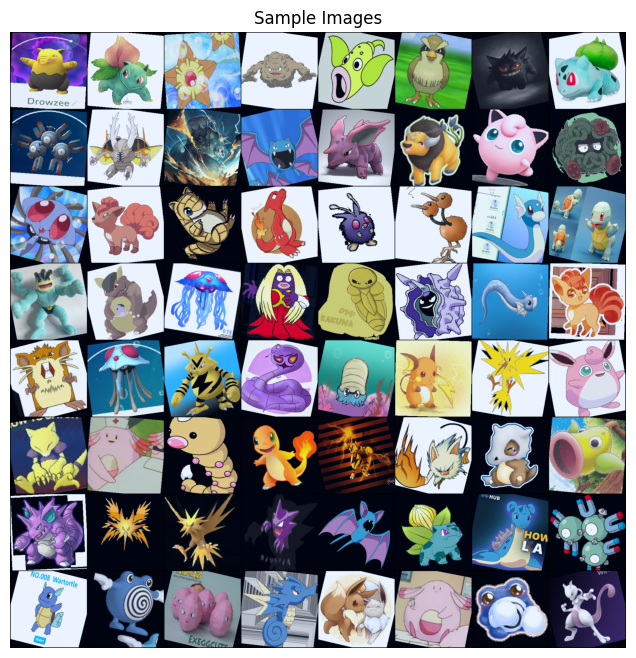

In [12]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

batch = next(iter(train_loader))
plt.figure(figsize = (8,8))
plt.axis("off")
plt.title("Sample Images")
plt.imshow(np.transpose(vutils.make_grid(batch[0][:64], padding = 2, normalize = True), (1,2,0)))

### Transfer Learning with ResNet101

In [ ]:
import torchvision.models as models
import torch.nn as nn
model = models.resnet18(pretrained = True)
model.fc = nn.Sequential(nn.Linear(512, 256),
                         nn.ReLU(),
                         nn.Linear(256, len(dataset.classes), bias = True))
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

### Training Model

In [ ]:
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr = .01)
criterion = nn.CrossEntropyLoss()

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        loss = criterion(outputs, labels)
        epoch_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


    print(f'Epoch : {epoch + 1} Loss: {epoch_loss / len(train_loader)}')

Epoch : 1 Loss: 2.9693200109080022
Epoch : 2 Loss: 1.0393883226930951
Epoch : 3 Loss: 0.5778636616309676
Epoch : 4 Loss: 0.4129987329280694
Epoch : 5 Loss: 0.2950795689602236


### Saving Model

In [ ]:
torch.save(model.state_dict(), 'models/pokemodel.pt')

### Evaluating Model

In [ ]:
def eval_model(model):
    correct = 0
    total = 0
    with torch.no_grad():
        for i, data in enumerate(dev_loader, 0):
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100.0 * correct / total
    print(f'Accuracy of model on test images: {test_acc}')
    return test_acc

In [ ]:
eval_model(model)

Accuracy of model on test images: 88.14073400060661


88.14073400060661